In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from Bio import Align

In [2]:
file_path = r"C:\Users\Tim\OneDrive\Documents\Copy of TOP_20_FOR_STRUCTURE(1).xlsx"
df = pd.read_excel(file_path, sheet_name="Sheet1")

In [3]:
# Extract kinase names and FASTA sequences
kinase_names = df['KINASE'].tolist()
sequences = df['FASTA'].dropna().tolist()

In [4]:
# Initialize Biopython's PairwiseAligner
aligner = Align.PairwiseAligner()
aligner.mode = 'global'  # Options: 'global' or 'local' alignment
aligner.match_score = 1
aligner.mismatch_score = -1
aligner.open_gap_score = -2
aligner.extend_gap_score = -0.5

In [5]:

# Perform pairwise sequence alignment for the first two sequences
if len(sequences) >= 2:
    seq1, seq2 = sequences[0], sequences[1]
    alignment = aligner.align(seq1, seq2)
    
    print(f"Alignment Score: {alignment.score}")
    print("\nAligned Sequences:\n")
    print(alignment[0])
else:
    print("Not enough sequences for alignment.")

# Generate conservation graph (based on sequence similarity)
conservation_scores = [
    aligner.score(sequences[i], sequences[i+1]) for i in range(len(sequences) - 1)
]

Alignment Score: -231.0

Aligned Sequences:

target            0 M--------------------------------------------------D---RS---
                  0 |--------------------------------------------------|---||---
query             0 MSNNGLDIQDKPPAPPMRNTSTMIGAGSKDAGTLNHGSKPLPPNPEEKKKKDRFYRSILP

target            4 ---------KE-NCISGP--VKATAPVGGPKRVLVTQQF---PCQNPLPVNSGQAQRVLC
                 60 ---------||-..||.|--...|..||---...||..|---|.|--------.|-|.|.
query            60 GDKTNKKKEKERPEISLPSDFEHTIHVG---FDAVTGEFTGMPEQ--------WA-RLLQ

target           49 PSN---SSQRIPLQAQKLV----SSHKPVQNQK-----QK---------QL--QATS---
                120 .||---|.|....||...|----.|.|....||-----.|---------.|--.|.|---
query           108 TSNITKSEQKKNPQAVLDVLEFYNSKKTSNSQKYMSFTDKSAEDYNSSNALNVKAVSETP

target           83 -VPHPVS------------------RPLNNTQKS------KQPLP------------SAP
                180 -||-|||------------------||-..|-||------..|||------------|..
query           168 AVP-PVSEDEDDDDDDATPPPVIAPRP-EHT-KSVYTRSVI

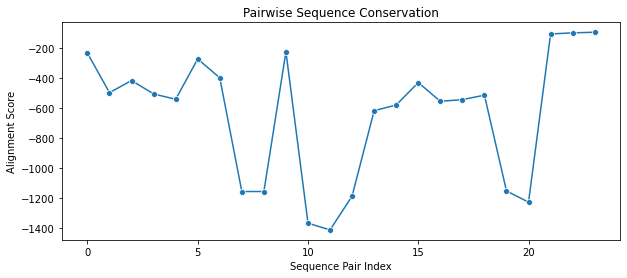

In [6]:
plt.figure(figsize=(10, 4))
sns.lineplot(x=range(len(conservation_scores)), y=conservation_scores, marker="o")
plt.xlabel("Sequence Pair Index")
plt.ylabel("Alignment Score")
plt.title("Pairwise Sequence Conservation")
plt.show()

In [7]:
import re

# Function to predict phosphorylation sites
def predict_phosphorylation_sites(sequence):
    motifs = [r"[ST]..[RK]", r"[ST]..Y"]  # Common phosphorylation motifs
    sites = []
    
    for motif in motifs:
        matches = re.finditer(motif, sequence)
        sites.extend([match.start() for match in matches])
    
    return sites

# Predict sites for all sequences
phospho_sites = {kinase_names[i]: predict_phosphorylation_sites(seq) for i, seq in enumerate(sequences)}

# Print results
for kinase, sites in phospho_sites.items():
    print(f"{kinase}: {sites}")

AURKA: [52, 65, 115, 122, 185, 216, 282, 336, 397, 203, 232, 291]
PAK1: [63, 114, 211, 138]
PDGFRB: [109, 222, 247, 372, 381, 448, 492, 637, 641, 649, 704, 987, 94, 200, 285, 747, 767, 1005]
LYN: [5, 36, 82, 437, 456, 488]
EGFR: [33, 49, 76, 94, 129, 185, 240, 289, 305, 353, 463, 483, 529, 677, 709, 724, 750, 956, 1027, 1095, 911, 994]
AKT1: [136, 159, 196, 210, 218, 239, 245, 432, 462, 171, 311]
TGFBR1: [60, 112, 164, 174, 199, 209, 240, 322, 394, 483, 95, 374]
DYRK1: [7, 12, 40, 126, 214, 251, 300, 476, 627, 705, 36, 323]
MTOR: [26, 35, 219, 247, 307, 349, 421, 445, 612, 624, 713, 917, 1020, 1024, 1035, 1086, 1137, 1507, 1581, 1651, 1706, 1767, 1784, 1892, 1983, 2164, 2213, 2220, 2366, 2433, 2441, 60, 140, 849, 925, 1583, 1696, 2034, 2445]
CDK1: [46, 52, 102, 239, 250, 73, 106, 165, 177]
CAMKK1: [56, 68, 148, 159, 451]
ATM: [20, 46, 88, 98, 150, 266, 296, 305, 327, 333, 371, 473, 529, 574, 655, 663, 688, 713, 760, 793, 823, 977, 1028, 1091, 1249, 1313, 1398, 1413, 1506, 1576, 1661, 1

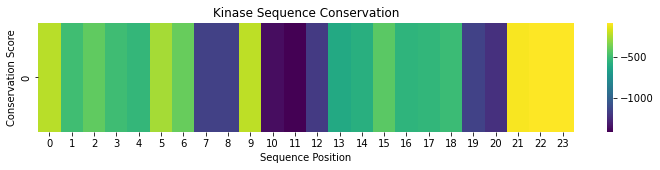

In [8]:
import numpy as np

# Convert conservation scores to a 2D array for visualization
conservation_matrix = np.array([conservation_scores])

# Save as an IDB-like heatmap
plt.figure(figsize=(12, 2))
sns.heatmap(conservation_matrix, cmap="viridis", cbar=True)
plt.xlabel("Sequence Position")
plt.ylabel("Conservation Score")
plt.title("Kinase Sequence Conservation")
plt.savefig("conservation_map.png", dpi=300)  # Save as an image
plt.show()

In [10]:
for site in phospho_sites["AURKA"]:
    print(sequences[0][site:site+4])  # Show surrounding motif

SSQR
SSHK
SKQK
SKKR
SHLR
TVYR
SSRR
TYKR
SASK
TRVY
TATY
TLDY


In [11]:
import re

def predict_phosphorylation_sites(sequence):
    motifs = [r"[ST][^P][^P][RK]", r"[ST]..Y"]  # Updated regex
    sites = []
    
    for motif in motifs:
        matches = re.finditer(motif, sequence)
        for match in matches:
            site = match.start()
            print(f"Motif: {sequence[site:site+4]} at Position: {site+1}")  # Print exact motif
            sites.append(site)
    
    return sites

# Run on AURKA
phospho_sites["AURKA"] = predict_phosphorylation_sites(sequences[0])

Motif: SSQR at Position: 53
Motif: SSHK at Position: 66
Motif: SKQK at Position: 116
Motif: SKKR at Position: 123
Motif: SHLR at Position: 186
Motif: TVYR at Position: 217
Motif: SSRR at Position: 283
Motif: TYKR at Position: 337
Motif: SASK at Position: 398
Motif: TRVY at Position: 204
Motif: TATY at Position: 233
Motif: TLDY at Position: 292


In [12]:
import re

def classify_phosphorylation_sites(sequence):
    motifs = {
        "Ser/Thr Kinase": r"[ST][^P][^P][RK]",  # Serine/Threonine Kinase Sites
        "Tyrosine Kinase": r"[ST]..Y"           # Tyrosine Kinase Sites
    }
    
    classified_sites = {"Ser/Thr Kinase": [], "Tyrosine Kinase": []}
    
    for kinase_type, motif in motifs.items():
        matches = re.finditer(motif, sequence)
        for match in matches:
            site = match.start() + 1  # Convert to 1-based index
            motif_seq = sequence[match.start():match.start() + 4]  # Extract motif
            classified_sites[kinase_type].append((site, motif_seq))
    
    return classified_sites

# Example: Run on AURKA sequence
aurka_sites = classify_phosphorylation_sites(sequences[0])

# Print results
for kinase_type, sites in aurka_sites.items():
    print(f"\n{kinase_type} Sites:")
    for site, motif in sites:
        print(f"  Position {site}: {motif}")


Ser/Thr Kinase Sites:
  Position 53: SSQR
  Position 66: SSHK
  Position 116: SKQK
  Position 123: SKKR
  Position 186: SHLR
  Position 217: TVYR
  Position 283: SSRR
  Position 337: TYKR
  Position 398: SASK

Tyrosine Kinase Sites:
  Position 204: TRVY
  Position 233: TATY
  Position 292: TLDY


In [22]:
import pandas as pd
import re

# Load the Excel file (replace with your filename)
file_path = r"C:\Users\Tim\OneDrive\Documents\Copy of TOP_20_FOR_STRUCTURE(1).xlsx"
df = pd.read_excel(file_path)

# Check the first few rows
print(df.head())

# Ensure the Excel file has 'KINASE' and 'FASTA' columns (case-sensitive)
if "KINASE" not in df.columns or "FASTA" not in df.columns:
    raise ValueError("Excel file must contain 'KINASE' and 'FASTA' columns.")

def classify_phosphorylation_sites(sequence):
    """
    Identifies phosphorylation motifs in kinase sequences.
    Returns a dictionary with classified sites.
    """
    motifs = {
        "Ser/Thr Kinase": r"[ST][^P][^P][RK]",  # Serine/Threonine Kinase Sites
        "Tyrosine Kinase": r"[ST]..Y"           # Tyrosine Kinase Sites
    }
    
    classified_sites = {"Ser/Thr Kinase": [], "Tyrosine Kinase": []}
    
    for kinase_type, motif in motifs.items():
        matches = re.finditer(motif, sequence)
        for match in matches:
            site = match.start() + 1  # Convert to 1-based index
            motif_seq = sequence[match.start():match.start() + 4]  # Extract motif
            classified_sites[kinase_type].append((site, motif_seq))
    
    return classified_sites

# Process all kinases
phospho_data = []

for index, row in df.iterrows():
    kinase_name = row["KINASE"]  # Ensure correct column name for kinase
    sequence = row["FASTA"]  # Ensure correct column name for sequence
    
    classified_sites = classify_phosphorylation_sites(sequence)
    
    for kinase_type, sites in classified_sites.items():
        for site, motif in sites:
            phospho_data.append([kinase_name, kinase_type, site, motif])

# Convert to DataFrame
phospho_df = pd.DataFrame(phospho_data, columns=["Kinase", "Type", "Position", "Motif"])

# Save results back to Excel
output_file = "kinase_phosphorylation_sites.xlsx"
phospho_df.to_excel(output_file, index=False)

print(f"Results saved to {output_file}")
print(phospho_df.head())

   KINASE                                              FASTA
0   AURKA  MDRSKENCISGPVKATAPVGGPKRVLVTQQFPCQNPLPVNSGQAQR...
1    PAK1  MSNNGLDIQDKPPAPPMRNTSTMIGAGSKDAGTLNHGSKPLPPNPE...
2  PDGFRB  MRLPGAMPALALKGELLLLSLLLLLEPQISQGLVVTPPGPELVLNV...
3     LYN  MGCIKSKGKDSLSDDGVDLKTQPVRNTERTIYVRDPTSNKQQRPVP...
4    EGFR  MRPSGTAGAALLALLAALCPASRALEEKKVCQGTSNKLTQLGTFED...
Results saved to kinase_phosphorylation_sites.xlsx
  Kinase            Type  Position Motif
0  AURKA  Ser/Thr Kinase        53  SSQR
1  AURKA  Ser/Thr Kinase        66  SSHK
2  AURKA  Ser/Thr Kinase       116  SKQK
3  AURKA  Ser/Thr Kinase       123  SKKR
4  AURKA  Ser/Thr Kinase       186  SHLR


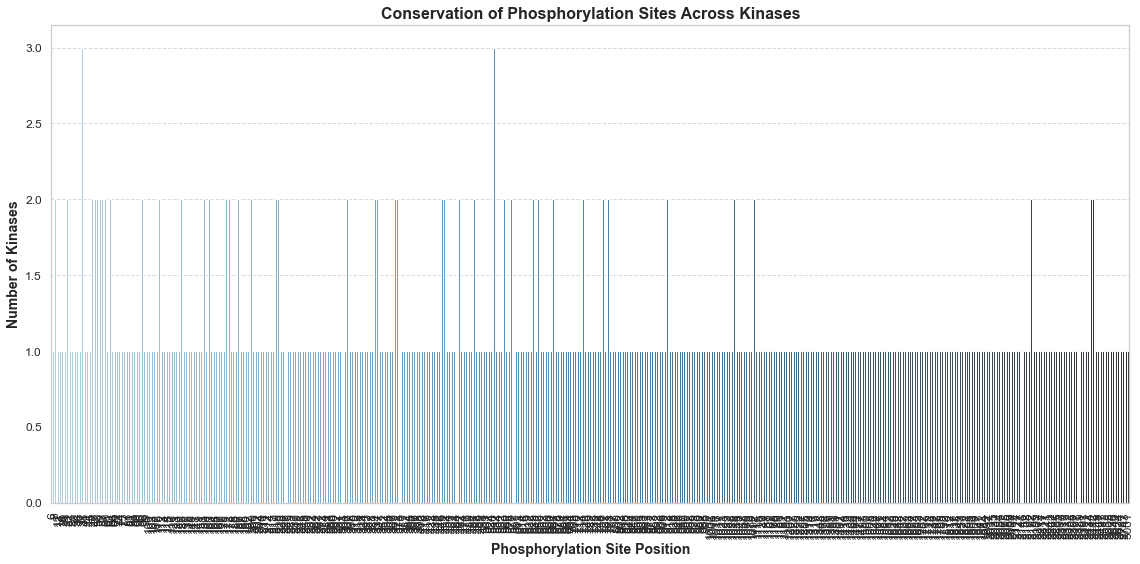

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count occurrences of phosphorylation positions across kinases
phospho_counts = phospho_df.groupby("Position").size().reset_index(name="Count")

# Increase plot size and adjust styling
plt.figure(figsize=(16, 8))  # Increase the size of the plot
sns.set(style="whitegrid")  # Set a more readable grid style

# Plot conservation graph with color palette adjustment
sns.barplot(data=phospho_counts, x="Position", y="Count", palette="Blues_d")

# Adding grid for better readability
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

# Labels and title with font adjustments for readability
plt.xlabel("Phosphorylation Site Position", fontsize=14, fontweight='bold')
plt.ylabel("Number of Kinases", fontsize=14, fontweight='bold')
plt.title("Conservation of Phosphorylation Sites Across Kinases", fontsize=16, fontweight='bold')

# Rotate labels for better visibility and adjust tick parameters
plt.xticks(rotation=90, fontsize=12)
plt.yticks(fontsize=12)

# Show the plot
plt.tight_layout()  # Adjust layout to avoid clipping
plt.show()


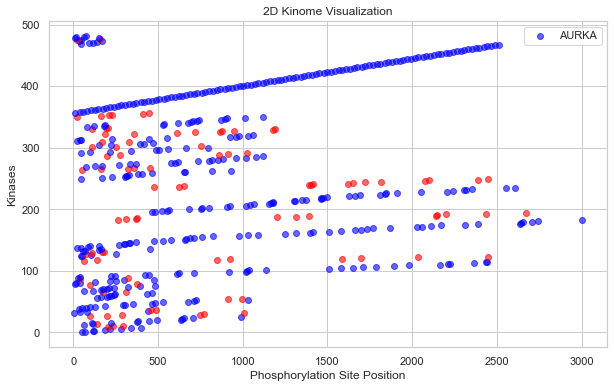

In [26]:
import matplotlib.pyplot as plt
import numpy as np

# Generate a simple 2D scatter plot to represent kinase sites
plt.figure(figsize=(10, 6))

for index, row in phospho_df.iterrows():
    kinase = row["Kinase"]
    pos = row["Position"]
    kinase_type = row["Type"]
    
    color = "red" if kinase_type == "Tyrosine Kinase" else "blue"
    plt.scatter(pos, index, color=color, label=kinase if index == 0 else "", alpha=0.6)

plt.xlabel("Phosphorylation Site Position")
plt.ylabel("Kinases")
plt.title("2D Kinome Visualization")
plt.legend()
plt.show()

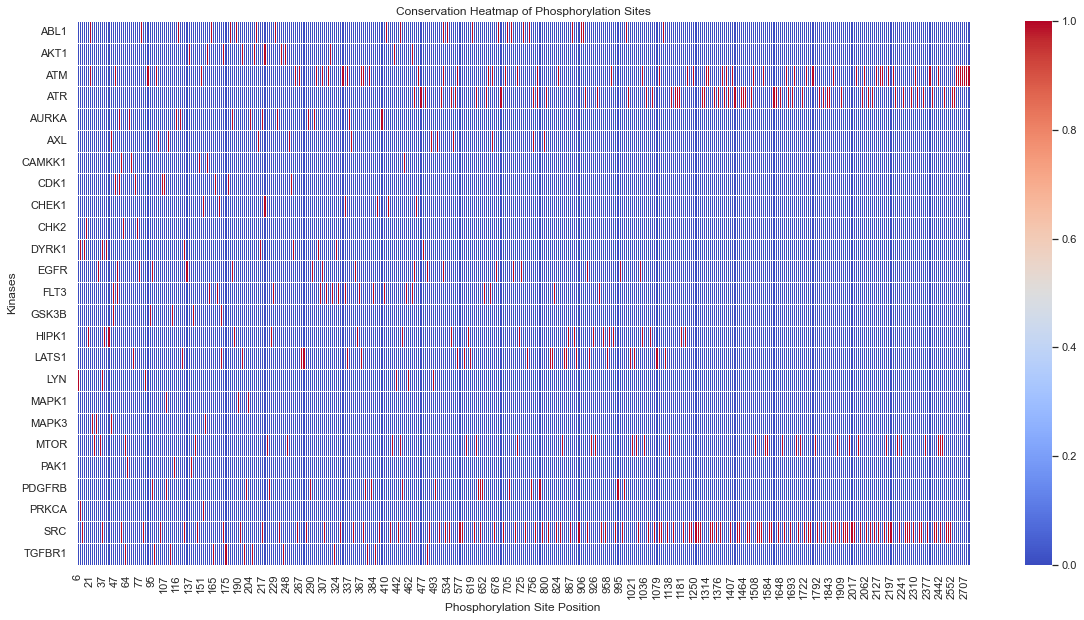

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pivot table for heatmap
heatmap_data = phospho_df.pivot_table(index="Kinase", columns="Position", values="Type", aggfunc='count').fillna(0)

# Plot the heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(heatmap_data, cmap="coolwarm", linewidths=0.5)

plt.xlabel("Phosphorylation Site Position")
plt.ylabel("Kinases")
plt.title("Conservation Heatmap of Phosphorylation Sites")

plt.show()

In [32]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score

In [33]:
# Load phosphorylation data
df = pd.read_excel(r"C:\Users\Tim\kinase_phosphorylation_sites.xlsx")

# Encode kinase types as numerical labels
label_encoder = LabelEncoder()
df["Type"] = label_encoder.fit_transform(df["Type"])

In [34]:
# Convert sequences to numerical features using ASCII encoding
def encode_sequence(seq):
    return [ord(c) for c in seq]  # Convert each character to ASCII

df["Encoded_Sequence"] = df["Motif"].apply(encode_sequence)

# Prepare feature matrix and labels
X = np.vstack(df["Encoded_Sequence"].values)  # Convert list of lists into array
y = df["Type"].values

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Dataset Prepared: {X_train.shape[0]} training samples, {X_test.shape[0]} test samples")

Dataset Prepared: 386 training samples, 97 test samples


In [35]:
# Train Random Forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Predict on test data
y_pred = clf.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 1.00


In [36]:
def predict_site(sequence):
    encoded_seq = np.array(encode_sequence(sequence)).reshape(1, -1)  # Convert to proper shape
    prediction = clf.predict(encoded_seq)
    predicted_type = label_encoder.inverse_transform(prediction)[0]
    return predicted_type

# Example: Predict phosphorylation type for a sample sequence
sample_seq = "SKQK"
predicted_type = predict_site(sample_seq)
print(f"Predicted Phosphorylation Type: {predicted_type}")

Predicted Phosphorylation Type: Ser/Thr Kinase


In [37]:
from Bio import Align
import matplotlib.pyplot as plt
import seaborn as sns

# Initialize aligner
aligner = Align.PairwiseAligner()
aligner.mode = "global"

# Example: Align two kinase sequences
seq1 = "MASSKQKQAKSL"
seq2 = "MASSSKQKQAKS"

alignment = aligner.align(seq1, seq2)
print(alignment[0])  # Display alignment

# Score of alignment (higher means more similarity)
alignment_score = alignment[0].score
print(f"Alignment Score: {alignment_score:.2f}")

target            0 MASS-KQKQAKSL 12
                  0 ||||-|||||||- 13
query             0 MASSSKQKQAKS- 12

Alignment Score: 11.00


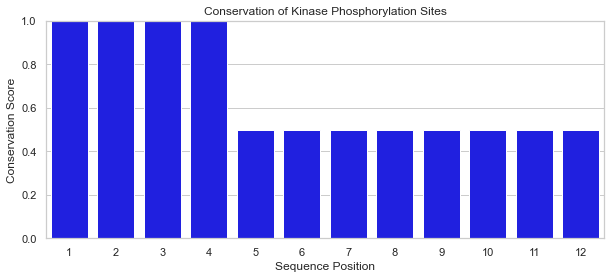

In [38]:
# Sample aligned sequences (normally from MSA)
aligned_sequences = [
    "MASSSKQKQAKS",
    "MASSKQKQAKSL",
    "MASSKQKQAKSL",
    "MASSSKQKQAKS"
]

# Calculate conservation per column
conservation_scores = []
for i in range(len(aligned_sequences[0])):
    column = [seq[i] for seq in aligned_sequences]
    most_common = max(set(column), key=column.count)  # Find most common residue
    conservation_scores.append(column.count(most_common) / len(column))

# Plot conservation scores
plt.figure(figsize=(10, 4))
sns.barplot(x=list(range(1, len(conservation_scores) + 1)), y=conservation_scores, color="blue")
plt.xlabel("Sequence Position")
plt.ylabel("Conservation Score")
plt.title("Conservation of Kinase Phosphorylation Sites")
plt.ylim(0, 1)
plt.show()

In [39]:
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import Draw

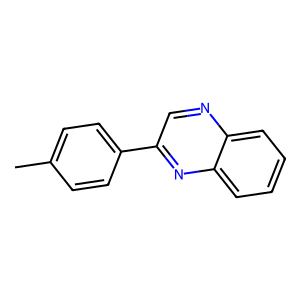

In [40]:
# Define a simple molecular backbone for kinases
kinase_smiles = "CC1=CC=C(C=C1)C2=NC3=CC=CC=C3N=C2"  # Example scaffold

# Convert to RDKit molecule object
mol = Chem.MolFromSmiles(kinase_smiles)

# Display molecule structure
Draw.MolToImage(mol)

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [42]:
# Example phosphorylation site positions (Replace with actual dataset)
phospho_sites = {
    "AURKA": [52, 65, 115, 122, 185, 216, 282, 336, 397, 203, 232, 291],
    "PAK1": [63, 114, 211, 138],
    "EGFR": [33, 49, 76, 94, 129, 185, 240, 289, 305, 353]
}

# Get kinase names
kinases = list(phospho_sites.keys())

# Prepare data for heatmap
max_length = max([max(sites) for sites in phospho_sites.values()])  # Find longest sequence
heatmap_data = np.zeros((len(kinases), max_length))

# Mark phosphorylation sites
for i, kinase in enumerate(kinases):
    for site in phospho_sites[kinase]:
        heatmap_data[i, site - 1] = 1  # Mark the site (adjusting for 0-based indexing)


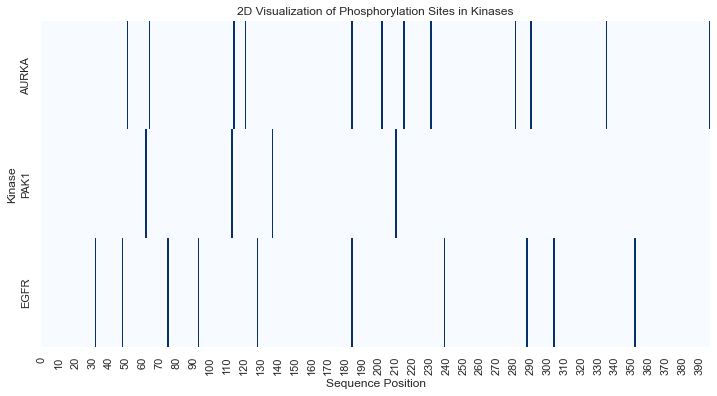

In [43]:
plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="Blues", cbar=False, xticklabels=10, yticklabels=kinases)
plt.xlabel("Sequence Position")
plt.ylabel("Kinase")
plt.title("2D Visualization of Phosphorylation Sites in Kinases")
plt.show()

In [44]:
!pip install logomaker
import logomaker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [45]:
# Example kinase sequences (replace with actual sequences from dataset)
kinase_sequences = {
    "AURKA": "MSSKQKVRLSKQKSKQRLSKQRLSKQRLSKQKSKQRLSKQ",
    "PAK1":  "MTRVLKRVSSHRRSSHRSSRRLKSHRSSHRRSSHRRSKQ",
    "EGFR":  "MSQKRSQKRSQRLSKQKSKQKRSQKRSQKRSQKRSQKRL"
}

# Extract motifs around phosphorylation sites
motif_length = 7  # Length of motif (e.g., 3 before & 3 after site)
motif_list = []

for kinase, sequence in kinase_sequences.items():
    sites = [i for i, aa in enumerate(sequence) if aa == "S"]  # Example: Looking for Serine (S)
    
    for site in sites:
        if site >= 3 and site <= len(sequence) - 4:  # Ensure full motif is available
            motif_list.append(sequence[site-3:site+4])

# Convert motifs into a DataFrame for visualization
df = pd.DataFrame([list(motif) for motif in motif_list])

# One-hot encode the sequences for the logo
one_hot = pd.get_dummies(df.stack()).groupby(level=1).sum()